In [ ]:
import os
import subprocess

subprocess.run(["java", "-version"])
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when

Khởi tạo môi trường xử lý big data cục bộ bằng Apache Spark
Build cấu hình bân đầu của spark, 
có thể scale tùy theo cấu hình máy local
master: CPU cores
driver.memory: Ram
executor memory: Là RAM cấp cho executor để giữ:
dữ liệu đang xử lý
intermediate results
hash tables khi join
buffers khi sort/shuffle
Shuffle partition: số chunks khi regroup data


In [ ]:
spark = SparkSession.builder \
    .appName("MIMIC_BigData_Project") \
    .master("local[4]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "16") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.1


In [3]:
spark.range(10).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
+---+



In [4]:
BASE_PATH = "../data"

HOSP = os.path.join(BASE_PATH, "hosp")
ICU = os.path.join(BASE_PATH, "icu")

Dùng Apache Spark để đọc các file CSV của MIMIC thành Spark DataFrames để xử lý big data.

In [5]:
patients = spark.read.csv(
    f"{HOSP}/patients.csv",
    header=True,
    inferSchema=True
)

admissions = spark.read.csv(
    f"{HOSP}/admissions.csv",
    header=True,
    inferSchema=True
)

d_icd_diagnoses = spark.read.csv(
    f"{HOSP}/d_icd_diagnoses.csv",
    header=True,
    inferSchema=True
)

diagnoses_icd = spark.read.csv(
    f"{HOSP}/diagnoses_icd.csv",
    header=True,
    inferSchema=True
)

d_labitems = spark.read.csv(
    f"{HOSP}/d_labitems.csv",
    header=True,
    inferSchema=True
)

procedures_icd = spark.read.csv(
    f"{HOSP}/procedures_icd.csv",
    header=True,
    inferSchema=True
)

d_icd_procedures = spark.read.csv(
    f"{HOSP}/d_icd_procedures.csv",
    header=True,
    inferSchema=True
)
d_items = spark.read.csv(
    f"{ICU}/d_items.csv",
    header=True,
    inferSchema=True
)

datetimeevents = spark.read.csv(
    f"{ICU}/datetimeevents.csv",
    header=True,
    inferSchema=True
)

icustays = spark.read.csv(
    f"{ICU}/icustays.csv",
    header=True,
    inferSchema=True
)

In [6]:
labevents = spark.read.csv(
    f"{HOSP}/labevents.csv",
    header=True,
    inferSchema=True
)

chartevents = spark.read.csv(
    f"{ICU}/chartevents.csv",
    header=True,
    inferSchema=True
)

inputevents = spark.read.csv(
    f"{ICU}/inputevents.csv",
    header=True,
    inferSchema=True
)

outputevents = spark.read.csv(
    f"{ICU}/outputevents.csv",
    header=True,
    inferSchema=True
)

procedureevents = spark.read.csv(
    f"{ICU}/procedureevents.csv",
    header=True,
    inferSchema=True
)

In [7]:
prescriptions = spark.read.csv(
    f"{HOSP}/prescriptions.csv",
    header=True,
    inferSchema=True
)

pharmacy = spark.read.csv(
    f"{HOSP}/pharmacy.csv",
    header=True,
    inferSchema=True
)

poe = spark.read.csv(
    f"{HOSP}/poe.csv",
    header=True,
    inferSchema=True
)

emar = spark.read.csv(
    f"{HOSP}/emar.csv",
    header=True,
    inferSchema=True
)

emar_detail = spark.read.csv(
    f"{HOSP}/emar_detail.csv",
    header=True,
    inferSchema=True
)

In [8]:
tables = {
    "patients": patients,
    "admissions": admissions,
    "d_icd_diagnoses": d_icd_diagnoses,
    "diagnoses_icd": diagnoses_icd,
    "d_labitems": d_labitems,
    "labevents": labevents,
    "procedures_icd": procedures_icd,
    "d_icd_procedures": d_icd_procedures,
    "d_items": d_items,
    "datetimeevents": datetimeevents,
    "icustays": icustays,
    "chartevents": chartevents,
    "inputevents": inputevents,
    "outputevents": outputevents,
    "procedureevents": procedureevents
}

In [9]:
tables.update({
    "prescriptions": prescriptions,
    "pharmacy": pharmacy,
    "poe": poe,
    "emar": emar,
    "emar_detail": emar_detail
})

In [10]:
for name, df in tables.items():
    print(f"{name}: {df.count()} rows")

patients: 100 rows
admissions: 275 rows
d_icd_diagnoses: 109775 rows
diagnoses_icd: 4506 rows
d_labitems: 1622 rows
labevents: 107727 rows
procedures_icd: 722 rows
d_icd_procedures: 85257 rows
d_items: 4014 rows
datetimeevents: 15280 rows
icustays: 140 rows
chartevents: 668862 rows
inputevents: 20404 rows
outputevents: 9362 rows
procedureevents: 1468 rows
prescriptions: 18087 rows
pharmacy: 15306 rows
poe: 45154 rows
emar: 35835 rows
emar_detail: 72018 rows


Kiểm tra schema (cấu trúc dữ liệu) của từng Spark DataFrame.

In [11]:
def inspect_schema(df, name):
    print(f"\n{name}")
    df.printSchema()

In [12]:
inspect_schema(patients, "patients")
inspect_schema(admissions, "admissions")
inspect_schema(diagnoses_icd, "diagnoses_icd")


patients
root
 |-- subject_id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- anchor_age: integer (nullable = true)
 |-- anchor_year: integer (nullable = true)
 |-- anchor_year_group: string (nullable = true)
 |-- dod: date (nullable = true)


admissions
root
 |-- subject_id: integer (nullable = true)
 |-- hadm_id: integer (nullable = true)
 |-- admittime: timestamp (nullable = true)
 |-- dischtime: timestamp (nullable = true)
 |-- deathtime: timestamp (nullable = true)
 |-- admission_type: string (nullable = true)
 |-- admit_provider_id: string (nullable = true)
 |-- admission_location: string (nullable = true)
 |-- discharge_location: string (nullable = true)
 |-- insurance: string (nullable = true)
 |-- language: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- race: string (nullable = true)
 |-- edregtime: timestamp (nullable = true)
 |-- edouttime: timestamp (nullable = true)
 |-- hospital_expire_flag: integer (nullable = true)


d

Check các dữ liệu bị miss

In [13]:
def check_missing(df, name):
    print(f"\n{name}")
    df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).show(truncate=False)
check_missing(patients, "patients")
check_missing(admissions, "admissions")


patients
+----------+------+----------+-----------+-----------------+---+
|subject_id|gender|anchor_age|anchor_year|anchor_year_group|dod|
+----------+------+----------+-----------+-----------------+---+
|0         |0     |0         |0          |0                |69 |
+----------+------+----------+-----------+-----------------+---+


admissions
+----------+-------+---------+---------+---------+--------------+-----------------+------------------+------------------+---------+--------+--------------+----+---------+---------+--------------------+
|subject_id|hadm_id|admittime|dischtime|deathtime|admission_type|admit_provider_id|admission_location|discharge_location|insurance|language|marital_status|race|edregtime|edouttime|hospital_expire_flag|
+----------+-------+---------+---------+---------+--------------+-----------------+------------------+------------------+---------+--------+--------------+----+---------+---------+--------------------+
|0         |0      |0        |0        |260   

Join 2 bảng để lấy thông tin patient disease 

In [14]:
patient_disease = diagnoses_icd.join(
    d_icd_diagnoses,
    ["icd_code", "icd_version"],
    "left"
)
patient_disease.show(10, truncate=False)

+--------+-----------+----------+--------+-------+--------------------------------------------------------------------------------------------+
|icd_code|icd_version|subject_id|hadm_id |seq_num|long_title                                                                                  |
+--------+-----------+----------+--------+-------+--------------------------------------------------------------------------------------------+
|4139    |9          |10035185  |22580999|3      |Other and unspecified angina pectoris                                                       |
|V707    |9          |10035185  |22580999|10     |Examination of participant in clinical trial                                                |
|41401   |9          |10035185  |22580999|1      |Coronary atherosclerosis of native coronary artery                                          |
|3899    |9          |10035185  |22580999|9      |Unspecified hearing loss                                                              

ETL_pipeline

import các hàm transformation/aggregation của Spark SQL

In [15]:
from pyspark.sql.functions import (
    col,
    trim,
    upper,
    to_timestamp,
    count,
    avg,
    desc,
    lit
)

data cleaning / preprocessing phase 

In [16]:
patients_clean = patients.dropDuplicates(["subject_id"])
admissions_clean = admissions.dropDuplicates(["hadm_id"])
admissions_clean = admissions_clean \
    .withColumn("admittime", to_timestamp("admittime")) \
    .withColumn("dischtime", to_timestamp("dischtime")) \
    .withColumn("deathtime", to_timestamp("deathtime"))
diagnoses_clean = diagnoses_icd.dropDuplicates()
d_icd_clean = d_icd_diagnoses.dropDuplicates()
procedures_clean = procedures_icd.dropDuplicates()
d_proc_clean = d_icd_procedures.dropDuplicates()
icustays_clean = icustays.dropDuplicates(["stay_id"])

In [17]:
patient_disease = diagnoses_clean.join(
    d_icd_clean,
    ["icd_code", "icd_version"],
    "left"
)
patient_disease = patient_disease.select(
    "subject_id",
    "hadm_id",
    "seq_num",
    "icd_code",
    "icd_version",
    "long_title"
)
patient_disease.show(10, truncate=False)

+----------+--------+-------+--------+-----------+------------------------------------------------------------------------------------+
|subject_id|hadm_id |seq_num|icd_code|icd_version|long_title                                                                          |
+----------+--------+-------+--------+-----------+------------------------------------------------------------------------------------+
|10035185  |22580999|8      |V1083   |9          |Personal history of other malignant neoplasm of skin                                |
|10009049  |22995465|4      |5601    |9          |Paralytic ileus                                                                     |
|10009035  |28324362|4      |V4589   |9          |Other postprocedural status                                                         |
|10009035  |28324362|2      |5121    |9          |Iatrogenic pneumothorax                                                             |
|10014729  |23300884|2      |5109    |9         

In [18]:
patient_procedure = procedures_clean.join(
    d_proc_clean,
    ["icd_code", "icd_version"],
    "left"
)
patient_procedure = patient_procedure.select(
    "subject_id",
    "hadm_id",
    "seq_num",
    "icd_code",
    "long_title"
)
patient_procedure.show(10, truncate=False)

+----------+--------+-------+--------+---------------------------------------------------------------------------------------------+
|subject_id|hadm_id |seq_num|icd_code|long_title                                                                                   |
+----------+--------+-------+--------+---------------------------------------------------------------------------------------------+
|10014729  |23300884|2      |3452    |Thoracoscopic decortication of lung                                                          |
|10014729  |28889419|4      |0390    |Insertion of catheter into spinal canal for infusion of therapeutic or palliative substances |
|10007818  |22987108|18     |02HV33Z |Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach                  |
|10007818  |22987108|2      |0W9G3ZX |Drainage of Peritoneal Cavity, Percutaneous Approach, Diagnostic                             |
|10007818  |22987108|14     |0W9G3ZZ |Drainage of Peritoneal Cavity, 

In [19]:
patient_outcome = patient_disease.join(
    admissions_clean.select(
        "hadm_id",
        "hospital_expire_flag",
        "admission_type",
        "insurance"
    ),
    "hadm_id",
    "left"
)
patient_outcome.show(10, truncate=False)

+--------+----------+-------+--------+-----------+------------------------------------------------------------------------------------+--------------------+--------------+---------+
|hadm_id |subject_id|seq_num|icd_code|icd_version|long_title                                                                          |hospital_expire_flag|admission_type|insurance|
+--------+----------+-------+--------+-----------+------------------------------------------------------------------------------------+--------------------+--------------+---------+
|22580999|10035185  |8      |V1083   |9          |Personal history of other malignant neoplasm of skin                                |0                   |URGENT        |Other    |
|22995465|10009049  |4      |5601    |9          |Paralytic ileus                                                                     |0                   |EW EMER.      |Other    |
|28324362|10009035  |4      |V4589   |9          |Other postprocedural status             

In [20]:
patient_icu = icustays_clean.join(
    admissions_clean.select(
        "hadm_id",
        "hospital_expire_flag"
    ),
    "hadm_id",
    "left"
)
patient_icu = patient_icu.select(
    "subject_id",
    "hadm_id",
    "stay_id",
    "first_careunit",
    "last_careunit",
    "los",
    "hospital_expire_flag"
)
patient_icu.show(10, truncate=False)

+----------+--------+--------+------------------------------------------------+------------------------------------------------+------------------+--------------------+
|subject_id|hadm_id |stay_id |first_careunit                                  |last_careunit                                   |los               |hospital_expire_flag|
+----------+--------+--------+------------------------------------------------+------------------------------------------------+------------------+--------------------+
|10023117  |28872262|30057454|Cardiac Vascular Intensive Care Unit (CVICU)    |Coronary Care Unit (CCU)                        |4.446550925925926 |0                   |
|10032725  |20611640|30101877|Medical/Surgical Intensive Care Unit (MICU/SICU)|Medical/Surgical Intensive Care Unit (MICU/SICU)|3.3496875         |0                   |
|10016742  |27568122|30425410|Medical Intensive Care Unit (MICU)              |Medical Intensive Care Unit (MICU)              |3.3498032407407403|0       

In [21]:
disease_frequency = patient_disease.groupBy("long_title") \
    .count() \
    .orderBy(desc("count"))
disease_frequency.show(20, truncate=False)

+----------------------------------------------------------------------------------------------------------------------+-----+
|long_title                                                                                                            |count|
+----------------------------------------------------------------------------------------------------------------------+-----+
|Unspecified essential hypertension                                                                                    |68   |
|Hyperlipidemia, unspecified                                                                                           |57   |
|Acute kidney failure, unspecified                                                                                     |56   |
|Other and unspecified hyperlipidemia                                                                                  |55   |
|Hypothyroidism, unspecified                                                                                   

In [22]:
d1 = patient_disease.alias("d1")
d2 = patient_disease.alias("d2")
disease_cooccurrence = d1.join(
    d2,
    (col("d1.hadm_id") == col("d2.hadm_id")) &
    (col("d1.long_title") < col("d2.long_title"))
)

disease_cooccurrence = disease_cooccurrence.select(
    col("d1.long_title").alias("disease_1"),
    col("d2.long_title").alias("disease_2")
)
disease_cooccurrence = disease_cooccurrence.groupBy(
    "disease_1",
    "disease_2"
).count().orderBy(desc("count"))
disease_cooccurrence.show(20, truncate=False)


+----------------------------------------------------------------------------------------------------------+------------------------------------------------------+-----+
|disease_1                                                                                                 |disease_2                                             |count|
+----------------------------------------------------------------------------------------------------------+------------------------------------------------------+-----+
|Other and unspecified hyperlipidemia                                                                      |Unspecified essential hypertension                    |31   |
|Hyperlipidemia, unspecified                                                                               |Hypothyroidism, unspecified                           |27   |
|Hyperlipidemia, unspecified                                                                               |Long term (current) use of insulin        

In [23]:
disease_mortality = patient_outcome.groupBy(
    "long_title"
).agg(
    avg("hospital_expire_flag").alias("mortality_rate"),
    count("*").alias("cases")
)
disease_mortality = disease_mortality.filter(
    col("cases") >= 5
).orderBy(desc("mortality_rate"))
disease_mortality.show(20, truncate=False)


+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------+-----+
|long_title                                                                                                                                                       |mortality_rate     |cases|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------+-----+
|Other medical procedures as the cause of abnormal reaction of the patient, or of later complication, without mention of misadventure at the time of the procedure|0.7142857142857143 |7    |
|Encounter for palliative care                                                                                                                                    |0.6923076923076923 |13   |
|Do not resuscitate status                        

In [24]:
patient_lab = labevents.join(
    d_labitems,
    "itemid",
    "left"
)
patient_lab = patient_lab.select(
    "subject_id",
    "hadm_id",
    "itemid",
    "label",
    "valuenum",
    "value",
    "flag"
)
patient_lab.show(10, truncate=False)
disease_lab = patient_disease.join(
    patient_lab,
    ["subject_id", "hadm_id"],
    "inner"
)
disease_lab.show(10, truncate=False)
patient_chart = chartevents.join(
    d_items,
    "itemid",
    "left"
)
patient_chart = patient_chart.select(
    "subject_id",
    "hadm_id",
    "stay_id",
    "itemid",
    "label",
    "value",
    "valuenum"
)
patient_chart.show(10, truncate=False)



+----------+--------+------+-----------------+--------+-----+--------+
|subject_id|hadm_id |itemid|label            |valuenum|value|flag    |
+----------+--------+------+-----------------+--------+-----+--------+
|10014354  |29600294|51277 |RDW              |15.4    |15.4 |NULL    |
|10014354  |29600294|51279 |Red Blood Cells  |3.35    |3.35 |abnormal|
|10014354  |29600294|52172 |RDW-SD           |49.7    |49.7 |abnormal|
|10014354  |29600294|51301 |White Blood Cells|20.3    |20.3 |abnormal|
|10014354  |29600294|51249 |MCHC             |31.1    |31.1 |abnormal|
|10014354  |29600294|51221 |Hematocrit       |29.6    |29.6 |abnormal|
|10014354  |29600294|51222 |Hemoglobin       |9.2     |9.2  |abnormal|
|10014354  |29600294|51265 |Platelet Count   |206.0   |206  |NULL    |
|10014354  |29600294|51250 |MCV              |88.0    |88   |NULL    |
|10014354  |29600294|51248 |MCH              |27.5    |27.5 |NULL    |
+----------+--------+------+-----------------+--------+-----+--------+
only s

In [27]:
import os

OUTPUT = "./processed"
os.makedirs(OUTPUT, exist_ok=True)

def save_pandas(df, name, sample_limit=None):
    if sample_limit:
        pdf = df.limit(sample_limit).toPandas()
    else:
        pdf = df.toPandas()

    path = f"{OUTPUT}/{name}.csv"
    pdf.to_csv(path, index=False)

    print(f"Saved: {path}")
save_pandas(patient_disease, "patient_disease")
save_pandas(patient_procedure, "patient_procedure")
save_pandas(disease_mortality, "disease_mortality")
save_pandas(disease_cooccurrence, "disease_cooccurrence")
save_pandas(disease_frequency, "disease_frequency")
save_pandas(patient_icu, "patient_icu")
save_pandas(patient_outcome, "patient_outcome")

Saved: ./processed/patient_disease.csv
Saved: ./processed/patient_procedure.csv
Saved: ./processed/disease_mortality.csv
Saved: ./processed/disease_cooccurrence.csv
Saved: ./processed/disease_frequency.csv
Saved: ./processed/patient_icu.csv
Saved: ./processed/patient_outcome.csv


Tạo các insight từ mimic

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

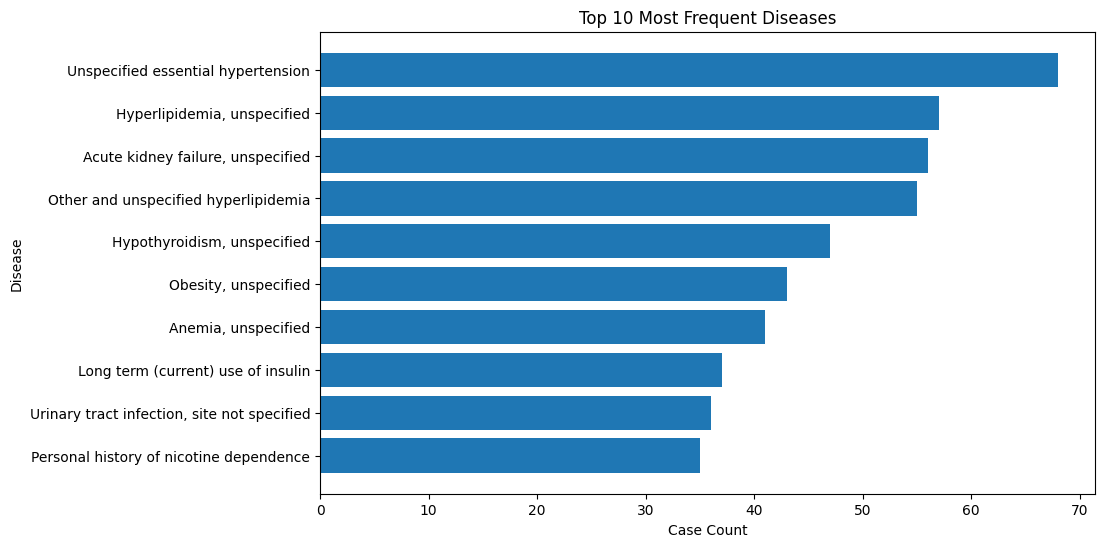

In [29]:

disease_freq_pd = disease_frequency.toPandas()
top10 = disease_freq_pd.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10["long_title"], top10["count"])
plt.xlabel("Case Count")
plt.ylabel("Disease")
plt.title("Top 10 Most Frequent Diseases")
plt.gca().invert_yaxis()
plt.show()